In [ ]:
# Install libraries

!pip install matplotlib-venn nltk textblob --quiet


In [ ]:
# Import libraries and download sentiment resources

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

from matplotlib_venn import venn2

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from itertools import combinations
import os

# Download VADER lexicon for sentiment
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# Upload CSV files
from google.colab import files
import os

uploaded = files.upload()   # choose cleaned_comments.csv and cleaned_captions.csv

# Use current working directory as base_path
base_path = "/content"
print("Base path set to:", base_path)
print("Uploaded files:", list(uploaded.keys()))

Saving cleaned_captions.csv to cleaned_captions.csv
Saving cleaned_comments.csv to cleaned_comments.csv
Base path set to: /content
Uploaded files: ['cleaned_captions.csv', 'cleaned_comments.csv']


In [ ]:
# Load datasets

comments_path = os.path.join(base_path, "cleaned_comments.csv")   # change name if needed
captions_path = os.path.join(base_path, "cleaned_captions.csv")   # change name if needed

df_comments = pd.read_csv(comments_path)
df_captions = pd.read_csv(captions_path)

print("Comments columns:", df_comments.columns.tolist())
print("Captions columns:", df_captions.columns.tolist())

Comments columns: ['username', 'timestamp', 'likes', 'comment_text', 'cleaned_tokens', 'tok_len', 'char_len', 'word_len']
Captions columns: ['caption_sentence', 'cleaned_tokens']


In [ ]:
# Join cleaned_tokens into a text column

def join_tokens_column(df, tokens_col_name, new_text_col_name):
    """
    Convert the 'cleaned_tokens' column into a single text string.
    Handles both list and string formats.
    """
    texts = []
    for value in df[tokens_col_name]:
        if isinstance(value, list):
            text = " ".join(value)
        else:
            # If it is already a cleaned string, just cast to str
            text = str(value)
        texts.append(text)
    df[new_text_col_name] = texts
    return df

df_comments = join_tokens_column(df_comments, "cleaned_tokens", "text")
df_captions = join_tokens_column(df_captions, "cleaned_tokens", "text")

df_comments[["cleaned_tokens", "text"]].head()

,cleaned_tokens,text
0,"['good', 'probably', 'need', 'updated', 'examp...","['good', 'probably', 'need', 'updated', 'examp..."
1,['amazing'],['amazing']
2,"['ngl', 'giant', 'twilio', 'advertisement']","['ngl', 'giant', 'twilio', 'advertisement']"
3,"['beast', 'father', 'lol', 'look', 'like', 'co...","['beast', 'father', 'lol', 'look', 'like', 'co..."
4,"['would', 'like', 'reach', 'brainstorming', 'w...","['would', 'like', 'reach', 'brainstorming', 'w..."


In [ ]:
# Compute top TF–IDF keywords

def compute_tfidf_keywords(text_series,
                           min_df_value,
                           max_df_value,
                           ngram_range_value,
                           top_n):
    """
    Compute TF–IDF and return a list of (term, score) sorted by score (desc).
    No slicing is used for selection of top_n.
    """
    vectorizer = TfidfVectorizer(
        min_df=min_df_value,
        max_df=max_df_value,
        ngram_range=ngram_range_value
    )

    tfidf_matrix = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()

    # Sum TF–IDF scores for each term across all documents
    term_scores = tfidf_matrix.sum(axis=0)
    term_scores = np.asarray(term_scores).flatten()

    # Create list of (index, score)
    index_score_pairs = []
    for index in range(len(feature_names)):
        score = term_scores[index]
        index_score_pairs.append((index, score))

    # Sort by score descending
    index_score_pairs_sorted = sorted(index_score_pairs,
                                      key=lambda x: x[1],
                                      reverse=True)

    # Pick top_n terms
    top_terms = []
    count = 0
    for index, score in index_score_pairs_sorted:
        term = feature_names[index]
        top_terms.append((term, float(score)))
        count = count + 1
        if count == top_n:
            break

    return top_terms, vectorizer, tfidf_matrix

In [ ]:
# === Cell 7: Part B - TF–IDF unigrams for comments and captions ===

# COMMENTS: unigrams
top_comments_unigrams, vec_comments_uni, tfidf_comments_uni = compute_tfidf_keywords(
    df_comments["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(1, 1),
    top_n=15
)

df_tfidf_comments = pd.DataFrame(top_comments_unigrams,
                                 columns=["term", "score"])
comments_keywords_path = os.path.join(base_path, "tfidf_keywords_comments.csv")
df_tfidf_comments.to_csv(comments_keywords_path, index=False)

# CAPTIONS: unigrams
top_captions_unigrams, vec_captions_uni, tfidf_captions_uni = compute_tfidf_keywords(
    df_captions["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(1, 1),
    top_n=15
)

df_tfidf_captions = pd.DataFrame(top_captions_unigrams,
                                 columns=["term", "score"])
captions_keywords_path = os.path.join(base_path, "tfidf_keywords_captions.csv")
df_tfidf_captions.to_csv(captions_keywords_path, index=False)

print("Saved:", comments_keywords_path)
print("Saved:", captions_keywords_path)

Saved: /content/tfidf_keywords_comments.csv
Saved: /content/tfidf_keywords_captions.csv


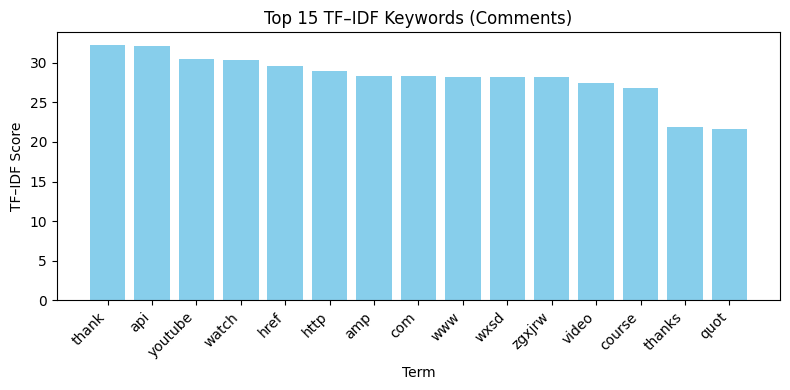

Saved keyword chart to: /content/tfidf_keywords_comments_bar.png


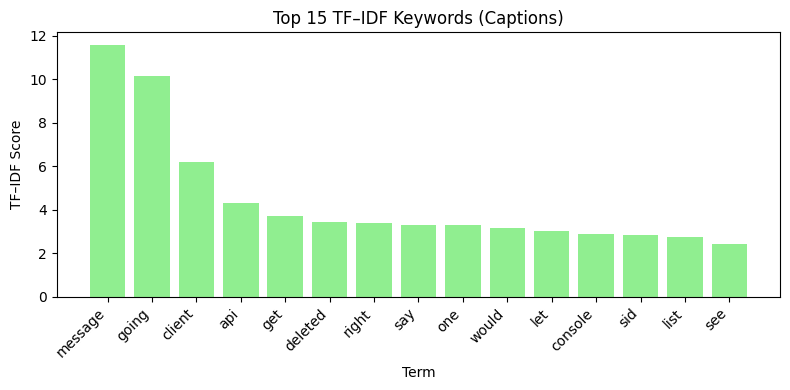

Saved keyword chart to: /content/tfidf_keywords_captions_bar.png


In [ ]:
# Bar charts for top TF–IDF keywords

def plot_tfidf_bar(df_keywords, title_text, save_path, bar_color):
    terms = list(df_keywords["term"])
    scores = list(df_keywords["score"])

    plt.figure(figsize=(8, 4))
    plt.bar(range(len(terms)), scores, color=bar_color)
    plt.xticks(range(len(terms)), terms, rotation=45, ha="right")
    plt.xlabel("Term")
    plt.ylabel("TF–IDF Score")
    plt.title(title_text)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved keyword chart to:", save_path)


# Paths
comments_keywords_chart = os.path.join(base_path, "tfidf_keywords_comments_bar.png")
captions_keywords_chart = os.path.join(base_path, "tfidf_keywords_captions_bar.png")

# Generate charts
plot_tfidf_bar(
    df_tfidf_comments,
    "Top 15 TF–IDF Keywords (Comments)",
    comments_keywords_chart,
    bar_color="skyblue"
)

plot_tfidf_bar(
    df_tfidf_captions,
    "Top 15 TF–IDF Keywords (Captions)",
    captions_keywords_chart,
    bar_color="lightgreen"
)

Only in comments: {'video', 'youtube', 'great', 'quot', 'http', 'href', 'course', 'www', 'watch', 'thank', 'spotify', 'amp', 'token', 'like', 'wxsd', 'thanks', 'zgxjrw'}
Only in captions: {'sid', 'going', 'want', 'back', 'one', 'error', 'deleted', 'function', 'say', 'list', 'right', 'see', 'message', 'would', 'console', 'client', 'let'}
Common: {'get', 'api', 'com'}


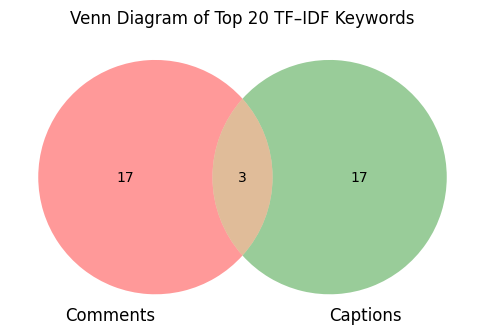

Saved Venn diagram to: /content/venn_keywords_comments_captions.png


In [ ]:
# Compare top 20 keywords and draw Venn diagram

# Get top 20 for comments
top_comments_20, _, _ = compute_tfidf_keywords(
    df_comments["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(1, 1),
    top_n=20
)

# Get top 20 for captions
top_captions_20, _, _ = compute_tfidf_keywords(
    df_captions["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(1, 1),
    top_n=20
)

comments_terms_20 = [term for term, score in top_comments_20]
captions_terms_20 = [term for term, score in top_captions_20]

set_comments = set(comments_terms_20)
set_captions = set(captions_terms_20)

intersection_terms = set_comments.intersection(set_captions)
only_comments = set_comments.difference(set_captions)
only_captions = set_captions.difference(set_comments)

print("Only in comments:", only_comments)
print("Only in captions:", only_captions)
print("Common:", intersection_terms)

# Venn diagram
plt.figure(figsize=(6, 6))
venn2(subsets=(len(only_comments),
               len(only_captions),
               len(intersection_terms)),
      set_labels=("Comments", "Captions"))
plt.title("Venn Diagram of Top 20 TF–IDF Keywords")
venn_path = os.path.join(base_path, "venn_keywords_comments_captions.png")
plt.savefig(venn_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Venn diagram to:", venn_path)

In [ ]:
# TF–IDF bigrams for comments and captions

# COMMENTS: bigrams
top_comments_bigrams, vec_comments_bi, tfidf_comments_bi = compute_tfidf_keywords(
    df_comments["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(2, 2),
    top_n=10
)
df_bigrams_comments = pd.DataFrame(top_comments_bigrams,
                                   columns=["bigram", "score"])
bigrams_comments_path = os.path.join(base_path, "tfidf_bigrams_comments.csv")
df_bigrams_comments.to_csv(bigrams_comments_path, index=False)

# CAPTIONS: bigrams
top_captions_bigrams, vec_captions_bi, tfidf_captions_bi = compute_tfidf_keywords(
    df_captions["text"],
    min_df_value=2,
    max_df_value=0.85,
    ngram_range_value=(2, 2),
    top_n=10
)
df_bigrams_captions = pd.DataFrame(top_captions_bigrams,
                                   columns=["bigram", "score"])
bigrams_captions_path = os.path.join(base_path, "tfidf_bigrams_captions.csv")
df_bigrams_captions.to_csv(bigrams_captions_path, index=False)

print("Saved:", bigrams_comments_path)
print("Saved:", bigrams_captions_path)

# Compare overlap
comments_bigram_set = set(df_bigrams_comments["bigram"])
captions_bigram_set = set(df_bigrams_captions["bigram"])

print("Common bigrams:", comments_bigram_set.intersection(captions_bigram_set))
print("Only comments bigrams:", comments_bigram_set.difference(captions_bigram_set))
print("Only captions bigrams:", captions_bigram_set.difference(comments_bigram_set))

Saved: /content/tfidf_bigrams_comments.csv
Saved: /content/tfidf_bigrams_captions.csv
Common bigrams: set()
Only comments bigrams: {'zgxjrw amp', 'wxsd zgxjrw', 'www youtube', 'href http', 'com watch', 'look like', 'api course', 'http www', 'youtube com', 'watch wxsd'}
Only captions bigrams: {'message client', 'going say', 'would deleted', 'going get', 'deleted message', 'going give', 'uri going', 'com api', 'say console', 'error console'}


In [ ]:
# Sentiment analysis for comments and captions

def add_sentiment_column(df, text_col_name, new_label_col_name):
    """
    Use VADER to compute compound score and map to:
    positive / neutral / negative.
    """
    sentiments = []
    for text in df[text_col_name]:
        text_str = str(text)
        score = sia.polarity_scores(text_str)["compound"]
        if score > 0.05:
            label = "positive"
        elif score < -0.05:
            label = "negative"
        else:
            label = "neutral"
        sentiments.append(label)
    df[new_label_col_name] = sentiments
    return df

df_comments = add_sentiment_column(df_comments, "text", "sentiment")
df_captions = add_sentiment_column(df_captions, "text", "sentiment")

df_comments["sentiment"].value_counts()

,count
sentiment,
neutral,963


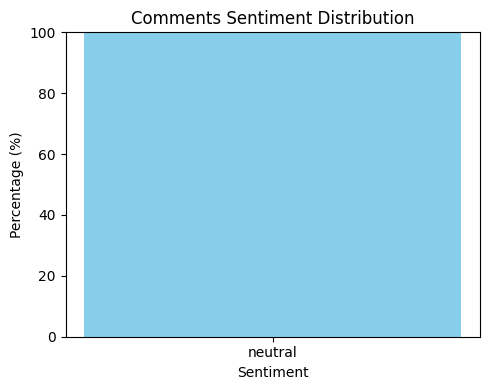

Saved chart to: /content/sentiment_comments_bar.png


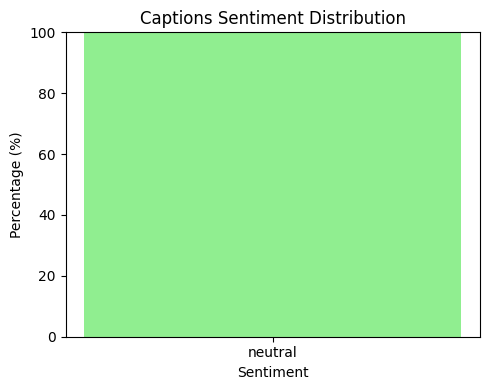

Saved chart to: /content/sentiment_captions_bar.png


In [ ]:
# Plot sentiment distributions

def plot_and_save_sentiment_bar(df, sentiment_col_name, title_text, save_path, bar_color):
    # Count sentiment categories
    counts = df[sentiment_col_name].value_counts()
    labels = list(counts.index)
    values = []
    total = counts.sum()

    # Convert counts → percentages
    for label in labels:
        value = counts[label]
        values.append(value * 100.0 / float(total))

    # Plot
    plt.figure(figsize=(5, 4))
    plt.bar(labels, values, color=bar_color)
    plt.xlabel("Sentiment")
    plt.ylabel("Percentage (%)")
    plt.title(title_text)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved chart to:", save_path)


# Paths to save charts
comments_sentiment_chart = os.path.join(base_path, "sentiment_comments_bar.png")
captions_sentiment_chart = os.path.join(base_path, "sentiment_captions_bar.png")

# Generate bar charts
plot_and_save_sentiment_bar(
    df_comments,
    "sentiment",
    "Comments Sentiment Distribution",
    comments_sentiment_chart,
    bar_color="skyblue"
)

plot_and_save_sentiment_bar(
    df_captions,
    "sentiment",
    "Captions Sentiment Distribution",
    captions_sentiment_chart,
    bar_color="lightgreen"
)

In [ ]:
# Save sentiment distribution

def sentiment_summary_to_csv(df, sentiment_col_name, save_path):
    counts = df[sentiment_col_name].value_counts()
    labels = list(counts.index)
    values = []
    total = counts.sum()

    for label in labels:
        value = counts[label]
        values.append(value * 100.0 / float(total))

    summary_rows = []
    for i in range(len(labels)):
        label = labels[i]
        percent = values[i]
        count = counts[labels[i]]
        summary_rows.append((label, count, percent))

    df_summary = pd.DataFrame(summary_rows,
                              columns=["sentiment", "count", "percentage"])
    df_summary.to_csv(save_path, index=False)
    print("Saved sentiment CSV to:", save_path)
    return df_summary

sentiment_comments_csv = os.path.join(
    base_path, "sentiment_summary_comments.csv"
)
sentiment_captions_csv = os.path.join(
    base_path, "sentiment_summary_captions.csv"
)

df_sent_comments = sentiment_summary_to_csv(df_comments,
                                            "sentiment",
                                            sentiment_comments_csv)

df_sent_captions = sentiment_summary_to_csv(df_captions,
                                            "sentiment",
                                            sentiment_captions_csv)

df_sent_comments, df_sent_captions

Saved sentiment CSV to: /content/sentiment_summary_comments.csv
Saved sentiment CSV to: /content/sentiment_summary_captions.csv


(  sentiment  count  percentage
 0   neutral    963       100.0,
   sentiment  count  percentage
 0   neutral     62       100.0)

In [ ]:
# Co-occurring keyword pairs from top TF–IDF terms

def compute_cooccurring_pairs(df, text_col_name, top_terms):
    """
    For each document, find which top_terms appear.
    Count how often each pair appears together in a document.
    """
    pair_counts = {}

    for text in df[text_col_name]:
        text_str = str(text)
        present_terms = []
        for term in top_terms:
            if term in text_str:
                present_terms.append(term)

        # Generate all pairs from present_terms
        for term1, term2 in combinations(sorted(present_terms), 2):
            pair = (term1, term2)
            if pair not in pair_counts:
                pair_counts[pair] = 0
            pair_counts[pair] = pair_counts[pair] + 1

    # Convert to DataFrame
    pairs_list = []
    for pair in pair_counts:
        count = pair_counts[pair]
        term1, term2 = pair
        pairs_list.append((term1, term2, count))

    df_pairs = pd.DataFrame(pairs_list,
                            columns=["term1", "term2", "count"])
    df_pairs = df_pairs.sort_values("count", ascending=False)
    return df_pairs

# Use the top 20 comment keywords computed earlier
top_comment_terms_for_pairs = [term for term, score in top_comments_20]

df_pairs_comments = compute_cooccurring_pairs(df_comments, "text",
                                              top_comment_terms_for_pairs)
pairs_comments_path = os.path.join(base_path,
                                   "cooccurring_pairs_comments.csv")
df_pairs_comments.to_csv(pairs_comments_path, index=False)

df_pairs_comments.head()

,term1,term2,count
13,com,watch,121
3,amp,com,120
16,com,youtube,119
18,href,http,117
12,com,http,117
